In [1]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline


### Reggression fundamentals:

In [2]:
rng = np.random.default_rng(seed = 100)
x_points = rng.integers(0, 10, 15)
noise = rng.normal(loc = 0, scale = 2.0, size = 15)

# to have a lineat relationship
y_points = 2*x_points +1 + noise
x_points, y_points

# creating a pair 
X = np.column_stack((x_points, y_points))
X

array([[ 7.        , 16.49012521],
       [ 8.        , 19.20869448],
       [ 1.        ,  7.48594479],
       [ 5.        ,  9.77701375],
       [ 0.        ,  1.09442237],
       [ 2.        ,  8.50846936],
       [ 4.        ,  6.32404027],
       [ 0.        ,  1.65114894],
       [ 5.        ,  9.62176457],
       [ 9.        , 18.96035638],
       [ 9.        , 19.94950649],
       [ 5.        ,  7.13779717],
       [ 4.        ,  7.01504344],
       [ 7.        , 12.18905783],
       [ 9.        , 18.53780898]])

In [3]:
mean = X.mean(axis = 0)
# centering the datapoints 
print(mean)
X_centre = X - mean
X_centre

[ 5.        10.9300796]


array([[ 2.        ,  5.5600456 ],
       [ 3.        ,  8.27861487],
       [-4.        , -3.44413481],
       [ 0.        , -1.15306585],
       [-5.        , -9.83565724],
       [-3.        , -2.42161024],
       [-1.        , -4.60603933],
       [-5.        , -9.27893066],
       [ 0.        , -1.30831503],
       [ 4.        ,  8.03027678],
       [ 4.        ,  9.01942689],
       [ 0.        , -3.79228243],
       [-1.        , -3.91503616],
       [ 2.        ,  1.25897823],
       [ 4.        ,  7.60772938]])

In [4]:
# we know g(w) = wT * C  * w -> where C(covarience matrix) = 1/n sum(xi*xiT) 
C = (np.dot(X_centre.T, X_centre))/len(X_centre)
C

array([[ 9.46666667, 17.48260063],
       [17.48260063, 37.28521869]])

In [5]:
# finding the eigen vectors and values 
eigen_vals, eigen_vectors = np.linalg.eig(C)
print(eigen_vals, eigen_vectors)

[ 1.0351888  45.71669656] [[-0.90072097 -0.43439813]
 [ 0.43439813 -0.90072097]]


In [6]:
#now that we have the eigen val we know we need the largest thus 
best_eigen = np.argmax(eigen_vals)
w_best = eigen_vectors[:, best_eigen]
# w_best #dont' forget its' eigen vectors like [[0,1],[0,1]]

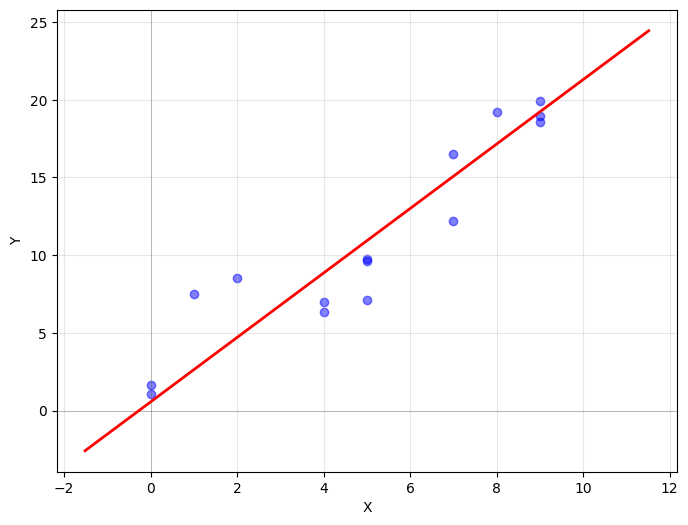

In [7]:
#done with all that le'ts plot 
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[:,0], X[:,1], color = 'blue', alpha = 0.5, label = "Orignal Points" )

line_t = np.array([-15,15])
line_x = mean[0] + line_t*w_best[0]
line_y = mean[1] + line_t*w_best[1]
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)
ax.grid(True, alpha=0.3)
ax.plot(line_x, line_y, color = 'red', linewidth = 2, label = "Best proxies")
plt.show()


In [9]:
from ipywidgets import interact
import ipywidgets as widgets

In [10]:
# @interact(R0=(0.9, 5.1, 0.1))
# def my_function(R0=2.4):
#     print(f"Reproduction number: {R0}")
# my_function()

In [ ]:
%matplotlib inline 

@interact(angle_degrees=(0, 180, 1))
def live_line(angle_degrees=45):
    theta = np.radians(angle_degrees)
    
    #map the theta with w
    w = np.array([np.cos(theta), np.sin(theta)])
    
    X_centre = X - mean
    scalars = X_centre @ w
    projections = np.outer(scalars, w) + mean # Add mean back to plot in original space
    #MSRE
    error = np.mean(np.linalg.norm(X - projections, axis=1)**2)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(X[:, 0], X[:, 1], color='blue', alpha=0.6, label='Original ponits', zorder=3)
    ax.scatter(mean[0], mean[1], color='red', s=100, zorder=5, label='Mean points')

    line_t = np.array([-15, 15])
    line_x = mean[0] + line_t * w[0]
    line_y = mean[1] + line_t * w[1]
    ax.plot(line_x, line_y, color='black', linewidth=2, label=f'Proxy Line (w)')
    
    for i in range(len(X)): #dash lines
        ax.plot([X[i, 0], projections[i, 0]], 
                [X[i, 1], projections[i, 1]], 
                color='red', linestyle='--', alpha=0.5)
        
    ax.set_title(f"Angle: {angle_degrees}°  |  Reconstruction Error: {error:.2f}", fontsize=14, fontweight='bold')
    ax.set_xlim(-5, 15)
    ax.set_ylim(-5, 25)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')
    
    plt.show()

interactive(children=(IntSlider(value=45, description='angle_degrees', max=180), Output()), _dom_classes=('wid…